**Physiscal activity analysis in relation to HRV metrics**

In [5]:
import pandas as pd
import os

# Set your local directory path
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

# Load the file
df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))

# 1. Total Number of Patients
num_patients = df['ID'].nunique()

# 2. Age Range
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
age_min = df['Age'].min()
age_max = df['Age'].max()

# 3. Number of Patients per Group of Exercise
# Make sure this string matches the column name in your Excel exactly
ex_label = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'

# Clean numeric data for this column
df[ex_label] = pd.to_numeric(df[ex_label], errors='coerce')

# Count patients per group (including NaNs if there are any)
patients_per_group = df[ex_label].value_counts().sort_index()

# PRINTING RESULTS
print(f"Total Patients: {num_patients}")
print(f"Age Range: {age_min} to {age_max} years")
print("\n--- Number of Patients per Exercise Group ---")
print(patients_per_group)

# Optional: Print the count of missing values in the exercise column
missing = df[ex_label].isna().sum()
if missing > 0:
    print(f"Note: {missing} patients have no exercise data recorded ('-').")

Total Patients: 353
Age Range: 17.0 to 85.0 years

--- Number of Patients per Exercise Group ---
Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)
0.0     73
1.0    114
2.0    103
3.0     30
4.0     16
Name: count, dtype: int64
Note: 17 patients have no exercise data recorded ('-').


1- Dose-response relationship - @article{seiler2007autonomic,
  title={Autonomic recovery after exercise in trained athletes},
  author={Seiler, Stephen},
  journal={Medicine \& Science in Sports \& Exercise},
  year={2007}
}

C:\Users\34673\AppData\Local\Temp\ipykernel_32636\1316393135.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(ax=axes[0], x=exercise_label, y='rmssd_ms', data=full_df, palette='viridis', ci=68)
C:\Users\34673\AppData\Local\Temp\ipykernel_32636\1316393135.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=exercise_label, y='rmssd_ms', data=full_df, palette='viridis', ci=68)
C:\Users\34673\AppData\Local\Temp\ipykernel_32636\1316393135.py:47: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 68)` for the same effect.

  sns.barplot(ax=axes[1], x=exercise_label, y='dfa_alpha1', data=full_df, palette='coolwarm', ci=68)
C:\Users\34673\AppData\Local\Temp\ipykernel_32636\1316393135.py:47: FutureWarning: 

Passing `palette` without assigni

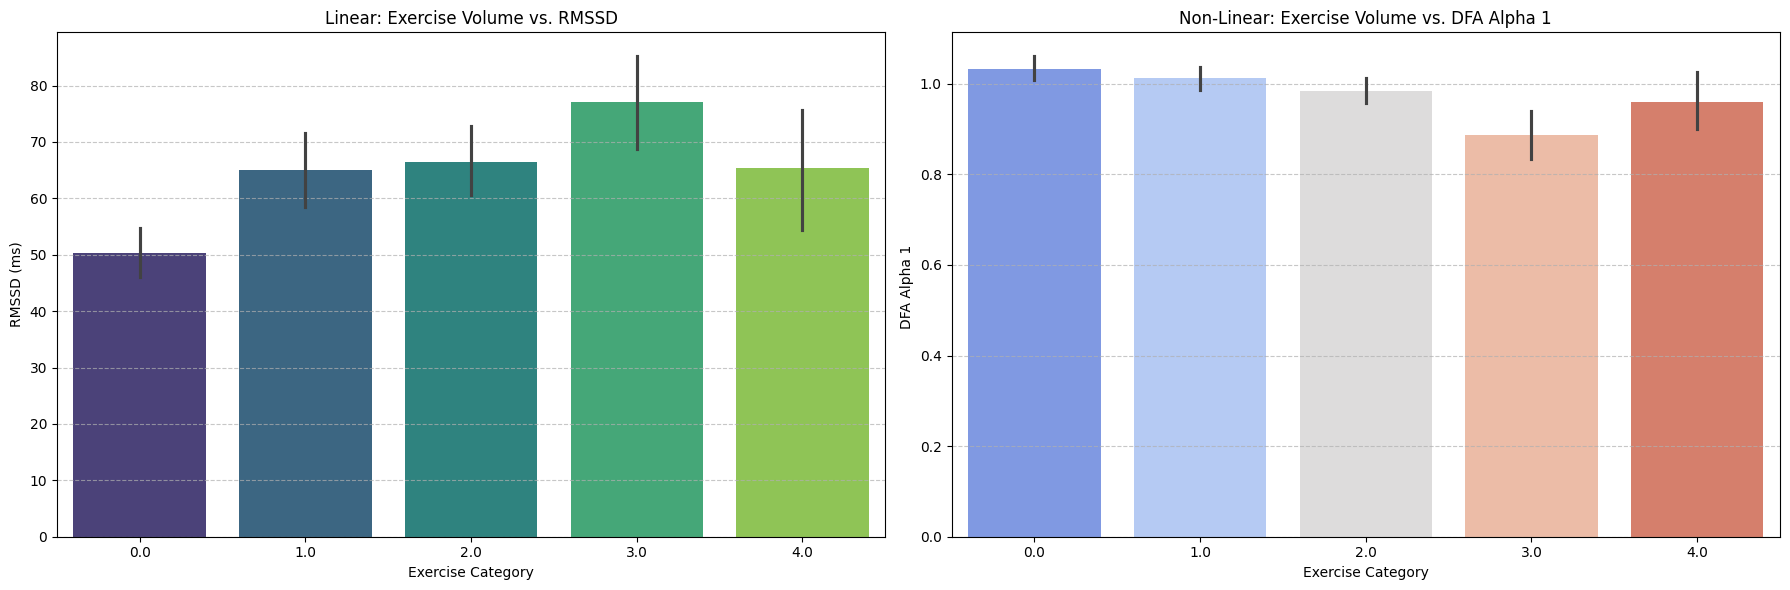

Summary Statistics by Exercise Category:
                                                     rmssd_ms  dfa_alpha1
Hours of exercise per week (0= none, 1= 1-2h, 2...                       
0.0                                                 50.397950    1.032885
1.0                                                 64.940858    1.011963
2.0                                                 66.444911    0.983986
3.0                                                 77.053354    0.887542
4.0                                                 65.363858    0.958694


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set your local directory path
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

# 1. Load files
linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))

# 2. Preprocessing
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})

exercise_cols = [
    'Age', 
    'Regular exercise (1=yes,0=no)', 
    'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'
]

for col in exercise_cols:
    exercise_df[col] = pd.to_numeric(exercise_df[col], errors='coerce')

# 3. Merge dataframes
hrv_merged = pd.merge(linear_df, non_linear_df, on='Patient_ID', how='inner')
full_df = pd.merge(hrv_merged, exercise_df, on='Patient_ID', how='inner')

exercise_label = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'
full_df = full_df.dropna(subset=[exercise_label])

# --- Plotting ---

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: RMSSD (Linear - Parasympathetic Activity)
sns.barplot(ax=axes[0], x=exercise_label, y='rmssd_ms', data=full_df, palette='viridis', ci=68)
axes[0].set_title('Linear: Exercise Volume vs. RMSSD')
axes[0].set_xlabel('Exercise Category')
axes[0].set_ylabel('RMSSD (ms)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: DFA Alpha 1 (Non-Linear - Fractal Scaling)
# Alpha 1 is widely used to monitor training load and autonomic balance.
sns.barplot(ax=axes[1], x=exercise_label, y='dfa_alpha1', data=full_df, palette='coolwarm', ci=68)
axes[1].set_title('Non-Linear: Exercise Volume vs. DFA Alpha 1')
axes[1].set_xlabel('Exercise Category')
axes[1].set_ylabel('DFA Alpha 1 ')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Optional: Print summary statistics for both features
print("Summary Statistics by Exercise Category:")
summary = full_df.groupby(exercise_label)[['rmssd_ms', 'dfa_alpha1']].mean()
print(summary)


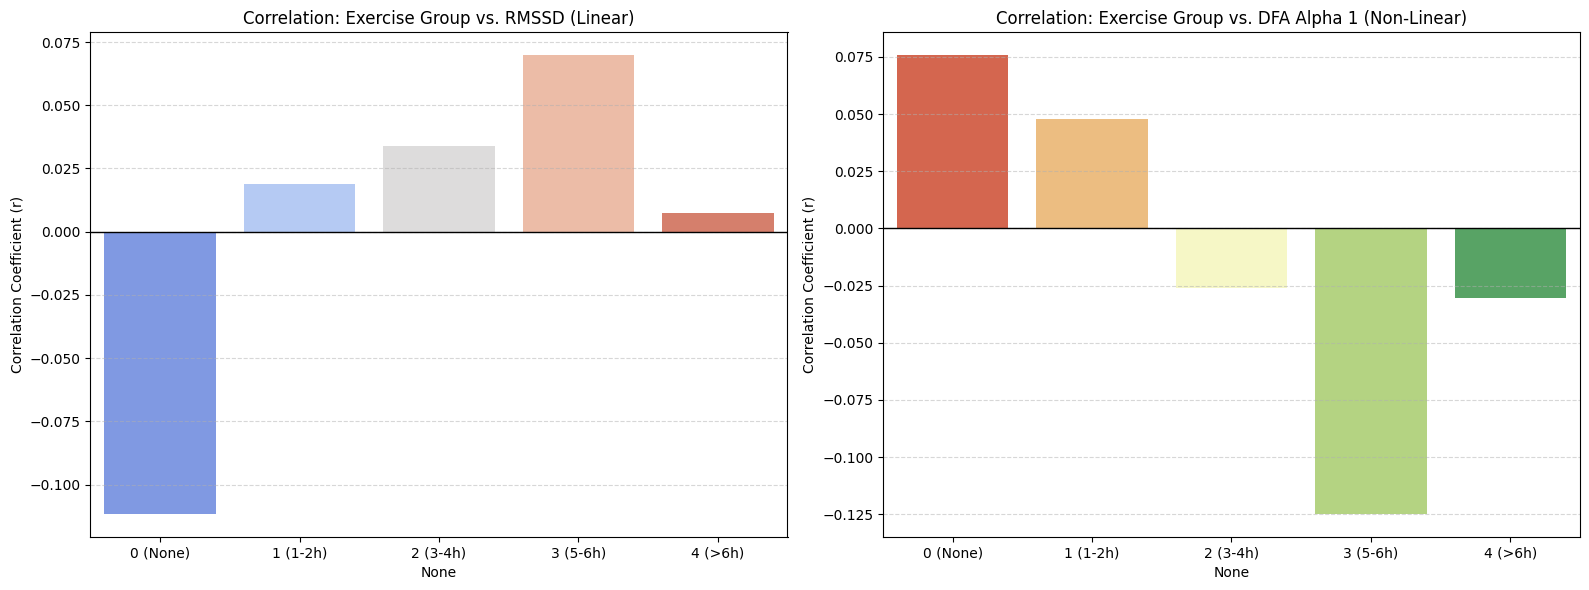

Group-wise correlation with RMSSD:
0 (None)   -0.111533
1 (1-2h)    0.018709
2 (3-4h)    0.033739
3 (5-6h)    0.069771
4 (>6h)     0.007391
Name: rmssd_ms, dtype: float64

Group-wise correlation with DFA Alpha 1:
0 (None)    0.075755
1 (1-2h)    0.047924
2 (3-4h)   -0.026195
3 (5-6h)   -0.124797
4 (>6h)    -0.030334
Name: dfa_alpha1, dtype: float64


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Paths
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

# 2. Data Loading
linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))

# 3. Merging
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})
ex_label = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'
for col in ['Age', ex_label]:
    exercise_df[col] = pd.to_numeric(exercise_df[col], errors='coerce')

full_df = pd.merge(pd.merge(linear_df, non_linear_df, on='Patient_ID'), exercise_df, on='Patient_ID').dropna(subset=[ex_label])

# 4. Dummy Variable Correlation Analysis
dummies = pd.get_dummies(full_df[ex_label], prefix='Group')

# --- Analysis for RMSSD ---
dummy_df_rmssd = pd.concat([full_df[['rmssd_ms']], dummies], axis=1)
corr_rmssd = dummy_df_rmssd.corr()['rmssd_ms'].drop('rmssd_ms')

# --- Analysis for DFA Alpha 1 ---
dummy_df_alpha = pd.concat([full_df[['dfa_alpha1']], dummies], axis=1)
corr_alpha = dummy_df_alpha.corr()['dfa_alpha1'].drop('dfa_alpha1')

# Set readable labels for the indices
group_labels = ['0 (None)', '1 (1-2h)', '2 (3-4h)', '3 (5-6h)', '4 (>6h)']
corr_rmssd.index = group_labels
corr_alpha.index = group_labels

# 5. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: RMSSD
sns.barplot(ax=axes[0], x=corr_rmssd.index, y=corr_rmssd.values, hue=corr_rmssd.index, palette='coolwarm', legend=False)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Correlation: Exercise Group vs. RMSSD (Linear)')
axes[0].set_ylabel('Correlation Coefficient (r)')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# Subplot 2: DFA Alpha 1
sns.barplot(ax=axes[1], x=corr_alpha.index, y=corr_alpha.values, hue=corr_alpha.index, palette='RdYlGn', legend=False)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Correlation: Exercise Group vs. DFA Alpha 1 (Non-Linear)')
axes[1].set_ylabel('Correlation Coefficient (r)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print the values
print("Group-wise correlation with RMSSD:")
print(corr_rmssd)
print("\nGroup-wise correlation with DFA Alpha 1:")
print(corr_alpha)


Age-related HRV decline with and with no exercise - @article{de1993heart,
  title={Heart rate variability and aerobic fitness},
  author={De Meersman, Ronald Edmond},
  journal={American heart journal},
  volume={125},
  number={3},
  pages={726--731},
  year={1993},
  publisher={Elsevier}
}

--- AGE-DECLINE SLOPES (RMSSD ms/year) ---
Gender        Status  Slope  P-value   N
  Male     Exerciser  0.850   0.0404 121
  Male Non-Exerciser -0.571   0.2670  28
Female     Exerciser  0.014   0.9703 140
Female Non-Exerciser -0.606   0.2112  43


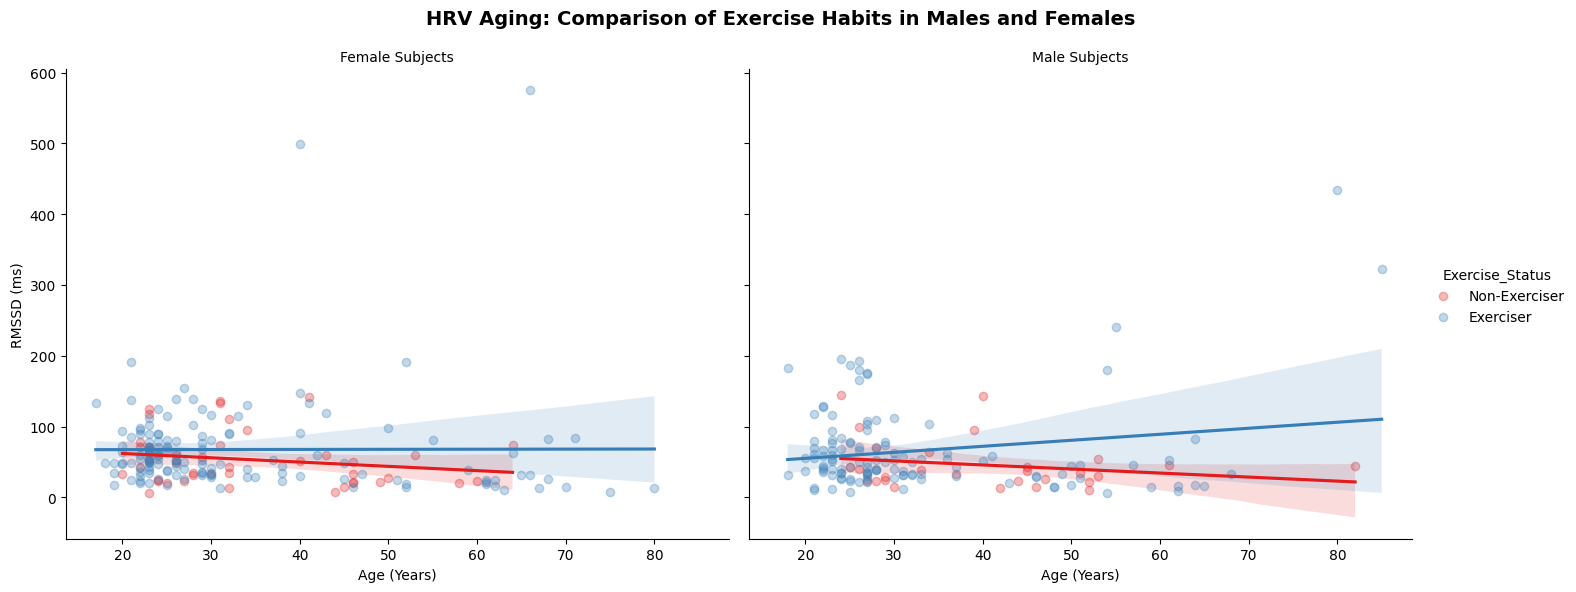

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy.stats import linregress

# 1. Setup Path and Load Data
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))
subject_df = pd.read_csv(os.path.join(path, 'subject-info.csv'))

# 2. Preprocessing & Merging
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})
subject_df = subject_df.rename(columns={'ID': 'Patient_ID'})

# Ensure IDs are numeric
for df in [linear_df, non_linear_df, exercise_df, subject_df]:
    df['Patient_ID'] = pd.to_numeric(df['Patient_ID'], errors='coerce')

ex_status_col = 'Regular exercise (1=yes,0=no)'

# Merge all datasets
full_df = pd.merge(linear_df, non_linear_df, on='Patient_ID')
full_df = pd.merge(full_df, exercise_df, on='Patient_ID')
full_df = pd.merge(full_df, subject_df[['Patient_ID', 'Sex']], on='Patient_ID')

# Clean data: Ensure Age and RMSSD are strictly numbers and drop missing values
full_df['Age'] = pd.to_numeric(full_df['Age'], errors='coerce')
full_df['rmssd_ms'] = pd.to_numeric(full_df['rmssd_ms'], errors='coerce')
full_df = full_df.dropna(subset=['Age', 'rmssd_ms', ex_status_col, 'Sex'])

# Map labels for plotting
full_df['Sex_Label'] = full_df['Sex'].map({1: 'Female', 0: 'Male'})
full_df['Exercise_Status'] = full_df[ex_status_col].map({1: 'Exerciser', 0: 'Non-Exerciser'})

# 3. ANALYSIS: Calculate Slopes with safety checks
print("--- AGE-DECLINE SLOPES (RMSSD ms/year) ---")
slope_results = []

for sex in ['Male', 'Female']:
    for status in ['Exerciser', 'Non-Exerciser']:
        # Filter subgroup
        subset = full_df[(full_df['Sex_Label'] == sex) & (full_df['Exercise_Status'] == status)]
        
        # Check: must have at least 3 points and variation in age to calculate a slope
        if len(subset) > 2 and subset['Age'].nunique() > 1:
            # .to_numpy() helps avoid the AttributeError with float objects
            x = subset['Age'].to_numpy(dtype=float)
            y = subset['rmssd_ms'].to_numpy(dtype=float)
            
            slope, intercept, r_val, p_val, std_err = linregress(x, y)
            
            slope_results.append({
                'Gender': sex,
                'Status': status,
                'Slope': round(slope, 3),
                'P-value': round(p_val, 4),
                'N': len(subset)
            })
        else:
            print(f"Skipping {sex} {status}: Not enough data points.")

slopes_df = pd.DataFrame(slope_results)
print(slopes_df.to_string(index=False))

# 4. VISUALIZATION
# Plot 1: Females (Exercise vs No Exercise)
# Plot 2: Males (Exercise vs No Exercise)
g = sns.lmplot(
    data=full_df, 
    x='Age', 
    y='rmssd_ms', 
    col='Sex_Label',      # Creates side-by-side plots for Male and Female
    hue='Exercise_Status', # Draws two lines (Exerciser vs Non-Exerciser) in each plot
    palette='Set1', 
    aspect=1.2, 
    height=6,
    scatter_kws={'alpha': 0.3}
)

# Customizing the appearance
g.set_axis_labels("Age (Years)", "RMSSD (ms)")
g.set_titles("{col_name} Subjects")
plt.subplots_adjust(top=0.88)
g.fig.suptitle('HRV Aging: Comparison of Exercise Habits in Males and Females', fontsize=14, fontweight='bold')

plt.show()


--- SUMMARY TABLE: ELDERLY PATIENTS (AGE >= 50) ---
   Regular Exercise (0/1)  Mean RMSSD     Std Dev  Sample Size (n)
0                     0.0   37.104643   18.794195               12
1                     1.0   74.784394  118.635184               42

--- AGE-HRV CORRELATION (BUFFER EFFECT) ---
Correlation Age vs RMSSD for Non-Exercisers: -0.221
Correlation Age vs RMSSD for Exercisers: 0.081


<Figure size 1000x600 with 0 Axes>

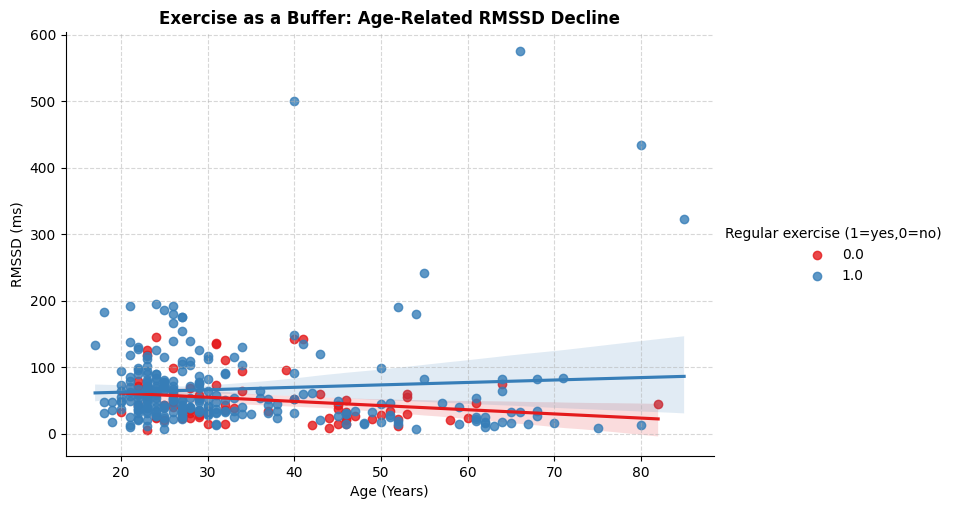

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Setup Path and Load Data
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

# Use pd.read_excel if using the original .xlsx file
linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))

# 2. Preprocessing & Merging
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})
ex_status_col = 'Regular exercise (1=yes,0=no)'
ex_hours_col = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'

# Clean numeric data
for col in ['Age', ex_status_col, ex_hours_col]:
    exercise_df[col] = pd.to_numeric(exercise_df[col], errors='coerce')

# Merge datasets
hrv_merged = pd.merge(linear_df, non_linear_df, on='Patient_ID')
full_df = pd.merge(hrv_merged, exercise_df, on='Patient_ID').dropna(subset=['Age', ex_status_col])

# 3. ANALYSIS: Elderly Patients (Age >= 50)
elderly_df = full_df[full_df['Age'] >= 50]

# Generate the requested Summary Table
elderly_stats = elderly_df.groupby(ex_status_col)['rmssd_ms'].agg(['mean', 'std', 'count']).reset_index()
elderly_stats.columns = ['Regular Exercise (0/1)', 'Mean RMSSD', 'Std Dev', 'Sample Size (n)']

print("--- SUMMARY TABLE: ELDERLY PATIENTS (AGE >= 50) ---")
print(elderly_stats)

# 4. ANALYSIS: Age-HRV Decline Buffer
# Correlation between Age and RMSSD within Exercisers vs Non-Exercisers
print("\n--- AGE-HRV CORRELATION (BUFFER EFFECT) ---")
for status in [0, 1]:
    subset = full_df[full_df[ex_status_col] == status]
    corr = subset[['Age', 'rmssd_ms']].corr().iloc[0, 1]
    label = "Exercisers" if status == 1 else "Non-Exercisers"
    print(f"Correlation Age vs RMSSD for {label}: {corr:.3f}")

# 5. Visualization
plt.figure(figsize=(10, 6))
sns.lmplot(x='Age', y='rmssd_ms', hue=ex_status_col, data=full_df, palette='Set1', aspect=1.5)
plt.title('Exercise as a Buffer: Age-Related RMSSD Decline', fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('RMSSD (ms)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

--- SUMMARY TABLE: ELDERLY PATIENTS (AGE >= 50) BY EXERCISE VOLUME ---
   Exercise Group  Mean RMSSD     Std Dev  Sample Size (n)
0             0.0   37.104643   18.794195               12
1             1.0   88.862417  140.418152               26
2             2.0   41.940608   63.009144               13
3             3.0  136.055309   77.421685                2
4             4.0   13.183182         NaN                1

--- AGE-HRV CORRELATION PER EXERCISE GROUP ---
   Group  Age_RMSSD_Correlation
0    0.0              -0.220516
1    1.0               0.220935
2    2.0              -0.125108
3    3.0               0.396829
4    4.0              -0.322720


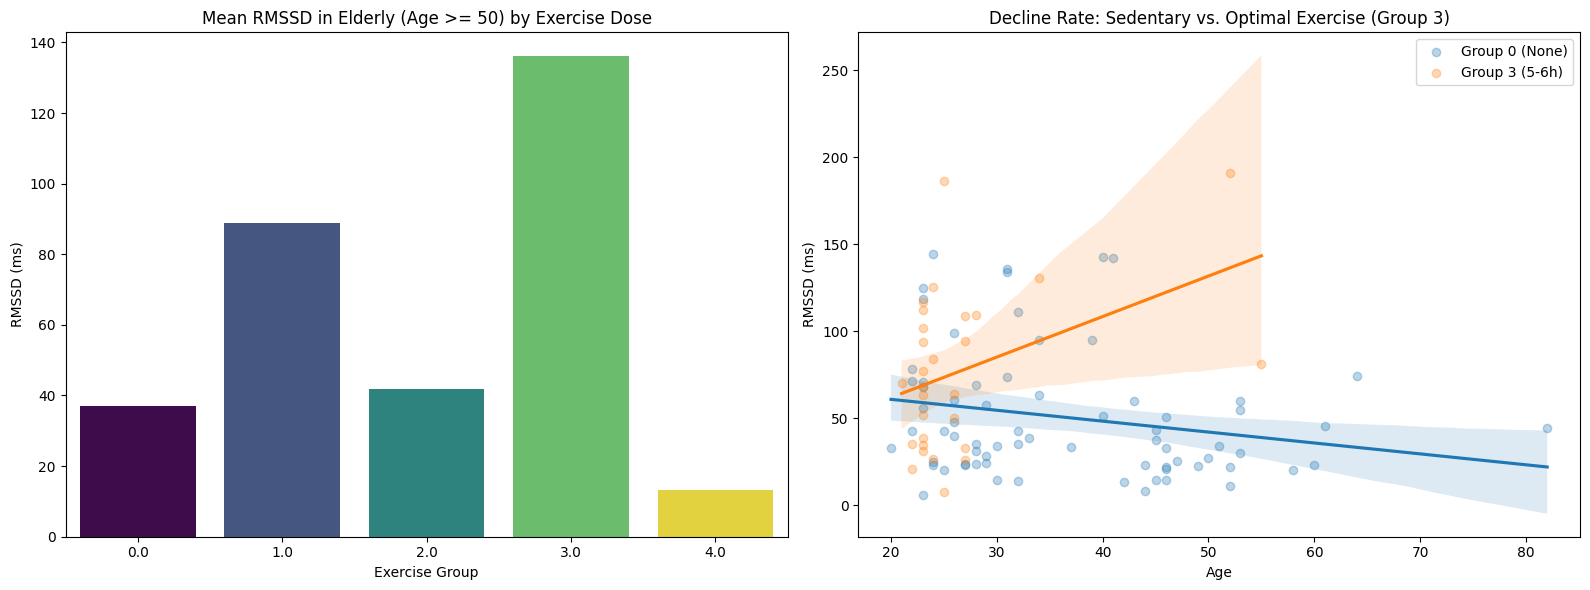

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Setup Path and Load Data
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))

# 2. Preprocessing & Merging
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})
ex_hours_col = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'

for col in ['Age', ex_hours_col]:
    exercise_df[col] = pd.to_numeric(exercise_df[col], errors='coerce')

full_df = pd.merge(pd.merge(linear_df, non_linear_df, on='Patient_ID'), exercise_df, on='Patient_ID').dropna(subset=['Age', ex_hours_col])

# 3. ANALYSIS: Comparison of HRV in the Elderly 
elderly_df = full_df[full_df['Age'] >= 50]
group_summary = elderly_df.groupby(ex_hours_col)['rmssd_ms'].agg(['mean', 'std', 'count']).reset_index()
group_summary.columns = ['Exercise Group', 'Mean RMSSD', 'Std Dev', 'Sample Size (n)']

print("--- SUMMARY TABLE: ELDERLY PATIENTS (AGE >= 50) BY EXERCISE VOLUME ---")
print(group_summary)

# 4. ANALYSIS: Age-RMSSD Correlation per Group (Checking the Buffer Gradient)
correlations = []
for group in sorted(full_df[ex_hours_col].unique()):
    subset = full_df[full_df[ex_hours_col] == group]
    if len(subset) > 5:
        r_val = subset[['Age', 'rmssd_ms']].corr().iloc[0, 1]
        correlations.append({'Group': group, 'Age_RMSSD_Correlation': r_val})

corr_df = pd.DataFrame(correlations)
print("\n--- AGE-HRV CORRELATION PER EXERCISE GROUP ---")
print(corr_df)

# 5. VISUALIZATION
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Mean RMSSD for Elderly by Group
sns.barplot(x='Exercise Group', y='Mean RMSSD', data=group_summary, ax=ax1, palette='viridis', hue='Exercise Group', legend=False)
ax1.set_title('Mean RMSSD in Elderly (Age >= 50) by Exercise Dose')
ax1.set_ylabel('RMSSD (ms)')

# Plot 2: Age vs RMSSD Regression per Group
# (We use a sample of groups or the lmplot approach for clarity)
sns.regplot(x='Age', y='rmssd_ms', data=full_df[full_df[ex_hours_col] == 0], label='Group 0 (None)', ax=ax2, scatter_kws={'alpha':0.3})
sns.regplot(x='Age', y='rmssd_ms', data=full_df[full_df[ex_hours_col] == 3], label='Group 3 (5-6h)', ax=ax2, scatter_kws={'alpha':0.3})
ax2.set_title('Decline Rate: Sedentary vs. Optimal Exercise (Group 3)')
ax2.set_xlabel('Age')
ax2.set_ylabel('RMSSD (ms)')
ax2.legend()

plt.tight_layout()
plt.show()

Statistical analysis - @article{dorey2019influence,
  title={The influence of aerobic fitness on electrocardiographic and heart rate variability parameters in young and older adults},
  author={Dorey, Tristan W and O'Brien, Myles W and Kimmerly, Derek S},
  journal={Autonomic Neuroscience},
  volume={217},
  pages={66--70},
  year={2019},
  publisher={Elsevier}
}

Loading files...


C:\Users\34673\AppData\Local\Temp\ipykernel_32636\3073264292.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dorey_Group', y='rmssd_ms', data=study_df, palette='Set2', ax=ax2)


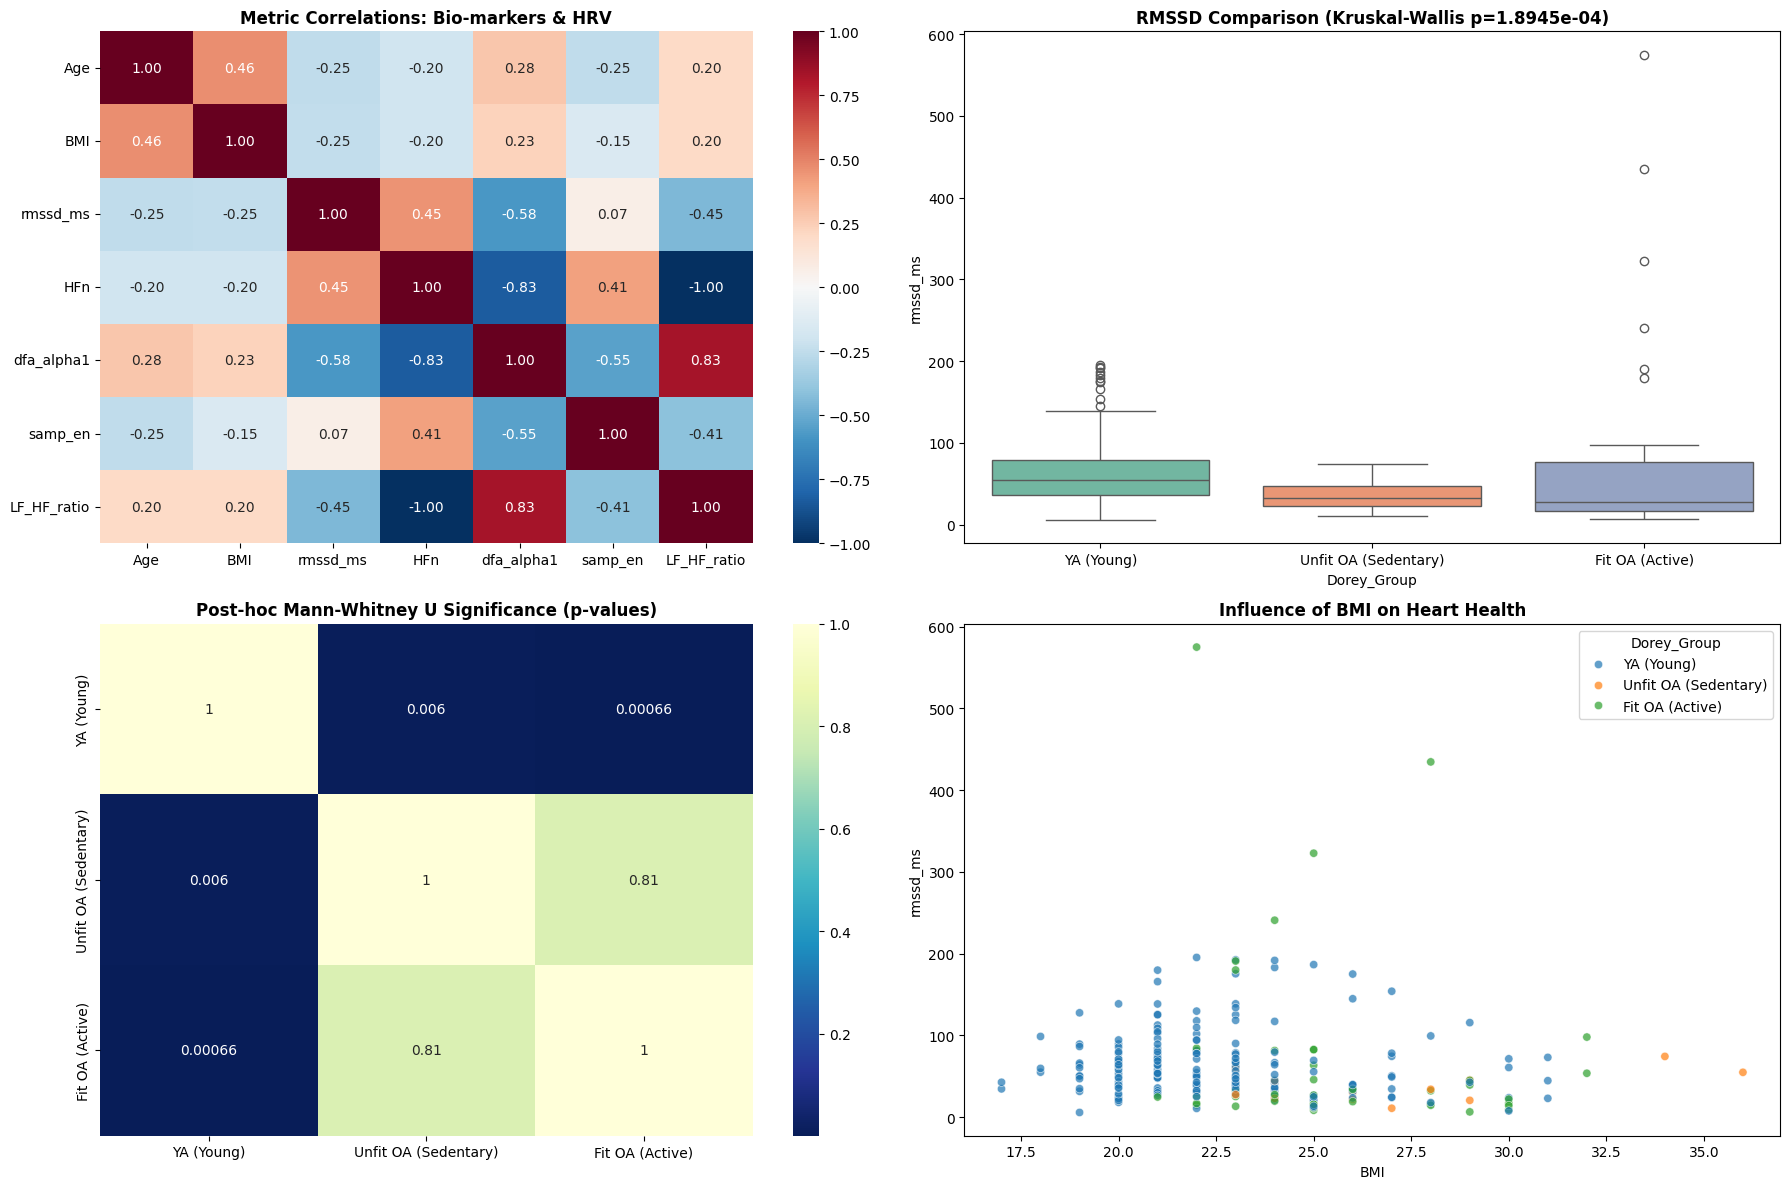


--- SUMMARY TABLE: STUDY GROUPS ---
                       rmssd_ms        BMI  Patient_ID
Dorey_Group                                           
Fit OA (Active)       74.784394  25.619048          42
Unfit OA (Sedentary)  37.104643  27.416667          12
YA (Young)            65.345530  22.510638         188


In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# 1. SETUP PATH AND LOAD DATA
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

print("Loading files...")
linear_df = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
non_linear_df = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
subject_info = pd.read_csv(os.path.join(path, 'subject-info.csv'))
# Update to read_excel if necessary
exercise_df = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx')) 

# 2. PREPROCESSING & MERGING
exercise_df = exercise_df.rename(columns={'ID': 'Patient_ID'})
subject_info = subject_info.rename(columns={'ID': 'Patient_ID'})
ex_status_col = 'Regular exercise (1=yes,0=no)'

for col in ['Age', 'BMI', ex_status_col]:
    if col in exercise_df.columns: exercise_df[col] = pd.to_numeric(exercise_df[col], errors='coerce')
    if col in subject_info.columns: subject_info[col] = pd.to_numeric(subject_info[col], errors='coerce')

# Merge all four datasets
df = pd.merge(pd.merge(linear_df, non_linear_df, on='Patient_ID'), 
              pd.merge(exercise_df, subject_info, on='Patient_ID'), on='Patient_ID').dropna(subset=['Age', 'BMI', 'rmssd_ms', ex_status_col])

# 3. DOREY ET AL. (2019) GROUPING
def categorize_dorey(row):
    if row['Age'] < 30: return 'YA (Young)'
    elif row['Age'] >= 50 and row[ex_status_col] == 1: return 'Fit OA (Active)'
    elif row['Age'] >= 50 and row[ex_status_col] == 0: return 'Unfit OA (Sedentary)'
    return 'Other'

df['Dorey_Group'] = df.apply(categorize_dorey, axis=1)
study_df = df[df['Dorey_Group'] != 'Other'].copy()

# 4. STATISTICAL TESTS
# Kruskal-Wallis H-test
groups = [study_df[study_df['Dorey_Group'] == g]['rmssd_ms'] for g in study_df['Dorey_Group'].unique()]
kw_stat, kw_p = stats.kruskal(*groups)

# 5. GENERATING VISUAL RESULTS (HEATMAPS & BOXPLOTS)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2)

# Plot 1: Correlation Heatmap (General)
ax1 = fig.add_subplot(gs[0, 0])
metrics = ['Age', 'BMI', 'rmssd_ms', 'HFn', 'dfa_alpha1', 'samp_en', 'LF_HF_ratio']
corr_matrix = df[metrics].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f", ax=ax1)
ax1.set_title('Metric Correlations: Bio-markers & HRV', fontweight='bold')

# Plot 2: Dorey Group Boxplots (RMSSD)
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(x='Dorey_Group', y='rmssd_ms', data=study_df, palette='Set2', ax=ax2)
ax2.set_title(f'RMSSD Comparison (Kruskal-Wallis p={kw_p:.4e})', fontweight='bold')

# Plot 3: Statistical Significance Heatmap (Mann-Whitney U p-values)
ax3 = fig.add_subplot(gs[1, 0])
labels = ['YA (Young)', 'Unfit OA (Sedentary)', 'Fit OA (Active)']
p_matrix = np.ones((3, 3))
for i, g1 in enumerate(labels):
    for j, g2 in enumerate(labels):
        if i < j:
            d1 = study_df[study_df['Dorey_Group'] == g1]['rmssd_ms']
            d2 = study_df[study_df['Dorey_Group'] == g2]['rmssd_ms']
            _, p = stats.mannwhitneyu(d1, d2)
            p_matrix[i, j] = p_matrix[j, i] = p
sns.heatmap(p_matrix, annot=True, xticklabels=labels, yticklabels=labels, cmap='YlGnBu_r', ax=ax3)
ax3.set_title('Post-hoc Mann-Whitney U Significance (p-values)', fontweight='bold')

# Plot 4: BMI vs RMSSD Scatter
ax4 = fig.add_subplot(gs[1, 1])
sns.scatterplot(x='BMI', y='rmssd_ms', hue='Dorey_Group', data=study_df, alpha=0.7, ax=ax4)
ax4.set_title('Influence of BMI on Heart Health', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n--- SUMMARY TABLE: STUDY GROUPS ---")
print(study_df.groupby('Dorey_Group').agg({'rmssd_ms': 'mean', 'BMI': 'mean', 'Patient_ID': 'count'}))


Sympathovagal balance - @article{sandercock2005effects,
  title={Effects of exercise on heart rate variability: inferences from meta-analysis},
  author={Sandercock, Gavin RH and Bromley, Paul D and Brodie, David A},
  journal={Medicine \& Science in Sports \& Exercise},
  volume={37},
  number={3},
  pages={433--439},
  year={2005}
}

C:\Users\34673\AppData\Local\Temp\ipykernel_32636\4035971922.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\34673\AppData\Local\Temp\ipykernel_32636\4035971922.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


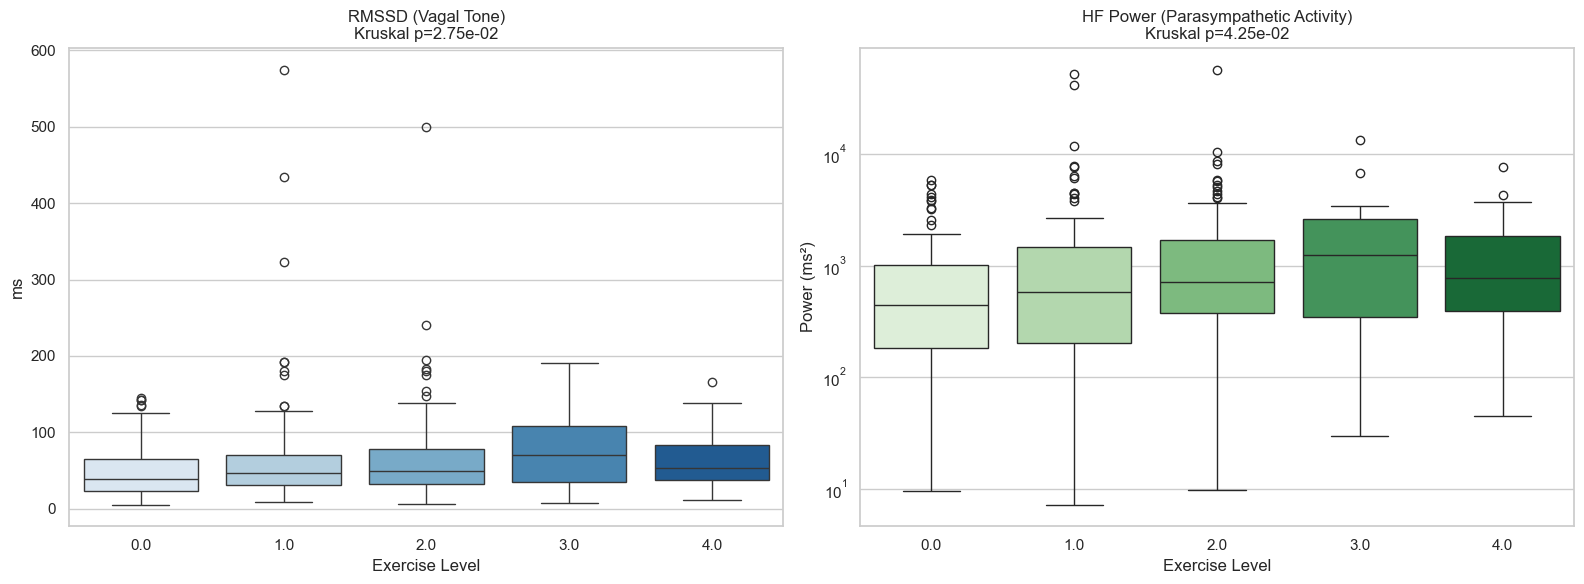

                                                     rmssd_ms       HF_ms2
Hours of exercise per week (0= none, 1= 1-2h, 2...                        
0.0                                                 38.622243   442.706501
1.0                                                 47.202461   580.755473
2.0                                                 49.078915   708.298248
3.0                                                 70.238230  1238.696737
4.0                                                 53.455487   778.561096


In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import os

# 1. SETUP PATHS
path = r"C:\Users\34673\Desktop\UNI\UNI 2025\TFG"

# 2. LOAD AND MERGE
df_linear = pd.read_csv(os.path.join(path, 'final_hrv_linear_results.csv'))
df_nonlin = pd.read_csv(os.path.join(path, 'final_hrv_non_linear_results.csv'))
df_exercise = pd.read_excel(os.path.join(path, 'exercise_info_age.xlsx'))
df_subject = pd.read_csv(os.path.join(path, 'subject-info.csv'))

df_exercise = df_exercise.rename(columns={'ID': 'Patient_ID'})
df_subject = df_subject.rename(columns={'ID': 'Patient_ID'})

ex_hours_col = 'Hours of exercise per week (0= none, 1= 1-2h, 2= 3-4h, 3= 5-6h, 4=>6h)'

df = pd.merge(
    pd.merge(df_linear, df_nonlin, on='Patient_ID'),
    pd.merge(df_exercise, df_subject, on='Patient_ID'),
    on='Patient_ID'
)

# 3. CLEAN NUMERIC DATA
metrics = ['rmssd_ms', 'HF_ms2', 'sdNN_ms', 'Age', 'BMI']

for col in metrics + [ex_hours_col]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=metrics + [ex_hours_col])

# 4. KRUSKAL-WALLIS TEST
results = {}

for metric in ['rmssd_ms', 'HF_ms2']:
    grouped = [
        df[df[ex_hours_col] == i][metric]
        for i in sorted(df[ex_hours_col].dropna().unique())
        if len(df[df[ex_hours_col] == i]) > 0
    ]
    stat, p = stats.kruskal(*grouped)
    results[metric] = p

# 5. VISUALIZATION (WITH COLOURS)
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSSD (Blues)
sns.boxplot(
    x=ex_hours_col,
    y='rmssd_ms',
    data=df,
    ax=axes[0],
    palette="Blues"
)
axes[0].set_title(f'RMSSD (Vagal Tone)\nKruskal p={results["rmssd_ms"]:.2e}')
axes[0].set_ylabel('ms')
axes[0].set_xlabel('Exercise Level')

# HF POWER (Greens)
sns.boxplot(
    x=ex_hours_col,
    y='HF_ms2',
    data=df,
    ax=axes[1],
    palette="Greens"
)
axes[1].set_title(f'HF Power (Parasympathetic Activity)\nKruskal p={results["HF_ms2"]:.2e}')
axes[1].set_ylabel('Power (ms²)')
axes[1].set_xlabel('Exercise Level')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

# 6. SUMMARY STATISTICS
summary = df.groupby(ex_hours_col)[['rmssd_ms', 'HF_ms2']].median()
print(summary)